In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

app = pd.read_csv("../data/raw/application_train.csv")

X = app.drop(columns=["TARGET", "SK_ID_CURR"])
y = app["TARGET"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Dev: ", X_dev.shape, "default rate:", round(y_dev.mean(), 4))
print("Test:", X_test.shape, "default rate:", round(y_test.mean(), 4))

Dev:  (246008, 120) default rate: 0.0807
Test: (61503, 120) default rate: 0.0807


## Evaluation rule

The dataset is split once into development and held-out test sets.

All exploratory analysis, feature engineering decisions, preprocessing
choices, and model selection are performed using `X_dev` and `y_dev`
only.

`X_test` and `y_test` remain untouched until the final evaluation.

This prevents information from the test set influencing modelling
decisions through repeated exploration. The final test score is therefore
a more honest estimate of performance on unseen data.

In [2]:
print("Development set:")
print("  X:", X_dev.shape)
print("  y:", y_dev.shape)
print("  Default rate:", y_dev.mean())

print("\nTest set:")
print("  X:", X_test.shape)
print("  y:", y_test.shape)
print("  Default rate:", y_test.mean())

Development set:
  X: (246008, 120)
  y: (246008,)
  Default rate: 0.08072908198107379

Test set:
  X: (61503, 120)
  y: (61503,)
  Default rate: 0.08072776937710356


## Missingness

Many features contain missing values. Rather than immediately dropping
columns with high missingness, first investigate whether the fact that a
value is missing is itself associated with the target.

All analysis below uses the development set only.

In [3]:
missing = (
    X_dev.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Columns with any missing:", (missing > 0).sum())
print("Columns with >50% missing:", (missing > 50).sum())

missing.head(20)

Columns with any missing: 67
Columns with >50% missing: 41


COMMONAREA_AVG              69.839599
COMMONAREA_MODE             69.839599
COMMONAREA_MEDI             69.839599
NONLIVINGAPARTMENTS_AVG     69.399776
NONLIVINGAPARTMENTS_MODE    69.399776
NONLIVINGAPARTMENTS_MEDI    69.399776
FONDKAPREMONT_MODE          68.377858
LIVINGAPARTMENTS_AVG        68.338835
LIVINGAPARTMENTS_MEDI       68.338835
LIVINGAPARTMENTS_MODE       68.338835
FLOORSMIN_MODE              67.851858
FLOORSMIN_AVG               67.851858
FLOORSMIN_MEDI              67.851858
YEARS_BUILD_AVG             66.478732
YEARS_BUILD_MODE            66.478732
YEARS_BUILD_MEDI            66.478732
OWN_CAR_AGE                 66.021430
LANDAREA_MEDI               59.341566
LANDAREA_AVG                59.341566
LANDAREA_MODE               59.341566
dtype: float64

## Does missingness carry signal?

A missing value is not necessarily random. For example, a property-related
field may be missing because the applicant does not own that type of
property.

For each feature with more than 50% missing values, compare the default
rate for rows where the feature is missing against rows where it is
present.

This analysis uses the development set only.

In [4]:
dev = X_dev.copy()
dev["TARGET"] = y_dev

print(dev.shape)

(246008, 121)


In [5]:
missing_pct = dev.isna().mean().sort_values(ascending=False)

high_missing = missing_pct[missing_pct > 0.5].index.tolist()

print(len(high_missing), "columns over 50% missing")
missing_pct.head(25)

41 columns over 50% missing


COMMONAREA_AVG              0.698396
COMMONAREA_MEDI             0.698396
COMMONAREA_MODE             0.698396
NONLIVINGAPARTMENTS_AVG     0.693998
NONLIVINGAPARTMENTS_MEDI    0.693998
NONLIVINGAPARTMENTS_MODE    0.693998
FONDKAPREMONT_MODE          0.683779
LIVINGAPARTMENTS_MEDI       0.683388
LIVINGAPARTMENTS_AVG        0.683388
LIVINGAPARTMENTS_MODE       0.683388
FLOORSMIN_MODE              0.678519
FLOORSMIN_AVG               0.678519
FLOORSMIN_MEDI              0.678519
YEARS_BUILD_MODE            0.664787
YEARS_BUILD_MEDI            0.664787
YEARS_BUILD_AVG             0.664787
OWN_CAR_AGE                 0.660214
LANDAREA_MEDI               0.593416
LANDAREA_AVG                0.593416
LANDAREA_MODE               0.593416
BASEMENTAREA_MEDI           0.584652
BASEMENTAREA_AVG            0.584652
BASEMENTAREA_MODE           0.584652
EXT_SOURCE_1                0.563376
NONLIVINGAREA_AVG           0.551299
dtype: float64

In [6]:
rows = []

for col in missing_pct[missing_pct > 0.1].index:
    if col == "TARGET":
        continue

    is_missing = dev[col].isna()

    rate_missing = dev.loc[is_missing, "TARGET"].mean()
    rate_present = dev.loc[~is_missing, "TARGET"].mean()

    rows.append({
        "column": col,
        "pct_missing": is_missing.mean(),
        "default_if_missing": rate_missing,
        "default_if_present": rate_present,
        "difference": rate_missing - rate_present,
    })

miss_df = (
    pd.DataFrame(rows)
    .sort_values("difference", key=abs, ascending=False)
)

miss_df.head(20)

,column,pct_missing,default_if_missing,default_if_present,difference
55,AMT_REQ_CREDIT_BUREAU_QRT,0.135134,0.103387,0.077189,0.026198
51,AMT_REQ_CREDIT_BUREAU_MON,0.135134,0.103387,0.077189,0.026198
52,AMT_REQ_CREDIT_BUREAU_WEEK,0.135134,0.103387,0.077189,0.026198
53,AMT_REQ_CREDIT_BUREAU_DAY,0.135134,0.103387,0.077189,0.026198
54,AMT_REQ_CREDIT_BUREAU_HOUR,0.135134,0.103387,0.077189,0.026198
56,AMT_REQ_CREDIT_BUREAU_YEAR,0.135134,0.103387,0.077189,0.026198
49,OCCUPATION_TYPE,0.312754,0.064921,0.087923,-0.023002
48,EMERGENCYSTATE_MODE,0.473891,0.092519,0.070109,0.022410
47,TOTALAREA_MODE,0.482533,0.092244,0.069992,0.022252
42,FLOORSMAX_MODE,0.497126,0.091809,0.069776,0.022034


In [7]:
for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    print(f"\n{col}")
    print("  missing:", round(dev[col].isna().mean(), 3))
    print("  corr with target:", round(dev[[col, "TARGET"]].corr().iloc[0, 1], 4))
    print("  mean if default:  ", round(dev.loc[dev.TARGET == 1, col].mean(), 4))
    print("  mean if no default:", round(dev.loc[dev.TARGET == 0, col].mean(), 4))


EXT_SOURCE_1
  missing: 0.563
  corr with target: -0.1554
  mean if default:   0.3862
  mean if no default: 0.511

EXT_SOURCE_2
  missing: 0.002
  corr with target: -0.1596
  mean if default:   0.4114
  mean if no default: 0.5233

EXT_SOURCE_3
  missing: 0.198
  corr with target: -0.1788
  mean if default:   0.3909
  mean if no default: 0.521


In [13]:
dev["ext_count"] = dev[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].notna().sum(axis=1)

dev.groupby("ext_count")["TARGET"].agg(["mean", "count"])

,mean,count
ext_count,,
0,0.086331,139
1,0.099433,29276
2,0.081621,128962
3,0.073159,87631


In [16]:
import matplotlib.pyplot as plt

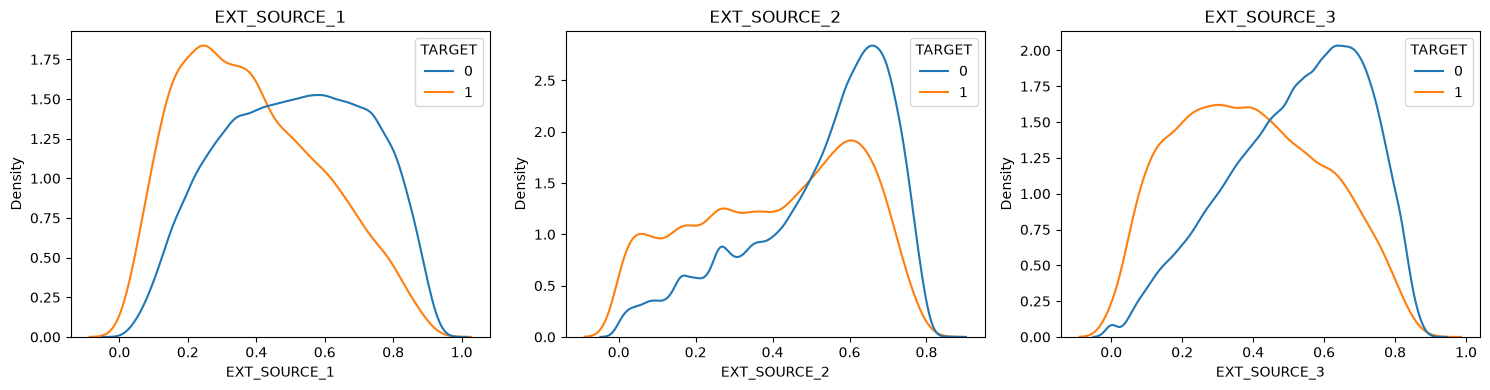

In [17]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    sns.kdeplot(
        data=dev,
        x=col,
        hue="TARGET",
        common_norm=False,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [18]:
print("DAYS_BIRTH:")
print(dev["DAYS_BIRTH"].describe())

print("\nDAYS_EMPLOYED:")
print(dev["DAYS_EMPLOYED"].describe())

print("\nCODE_GENDER:")
print(dev["CODE_GENDER"].value_counts())

print("\nAMT_INCOME_TOTAL:")
print(dev["AMT_INCOME_TOTAL"].describe())

DAYS_BIRTH:
count    246008.000000
mean     -16029.515882
std        4362.869037
min      -25229.000000
25%      -19673.000000
50%      -15744.000000
75%      -12401.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

DAYS_EMPLOYED:
count    246008.000000
mean      63581.163637
std      141081.696923
min      -17912.000000
25%       -2762.000000
50%       -1215.000000
75%        -291.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

CODE_GENDER:
CODE_GENDER
F      161887
M       84119
XNA         2
Name: count, dtype: int64

AMT_INCOME_TOTAL:
count    2.460080e+05
mean     1.688532e+05
std      2.589606e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.476000e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


In [19]:
anomaly = dev["DAYS_EMPLOYED"] == 365243

print("Rows with DAYS_EMPLOYED = 365243:", anomaly.sum())
print("Percentage:", round(anomaly.mean() * 100, 2), "%")

print("Default rate for anomaly group:",
      round(dev.loc[anomaly, "TARGET"].mean(), 4))

print("Default rate for other applicants:",
      round(dev.loc[~anomaly, "TARGET"].mean(), 4))

Rows with DAYS_EMPLOYED = 365243: 44143
Percentage: 17.94 %
Default rate for anomaly group: 0.0537
Default rate for other applicants: 0.0866


In [29]:
anom = dev[dev["DAYS_EMPLOYED"] == 365243]

print(anom["NAME_INCOME_TYPE"].value_counts())

NAME_INCOME_TYPE
Pensioner     44126
Unemployed       17
Name: count, dtype: int64


In [20]:
print(dev["CODE_GENDER"].value_counts(dropna=False))

CODE_GENDER
F      161887
M       84119
XNA         2
Name: count, dtype: int64


In [21]:
print(dev["AMT_INCOME_TOTAL"].nlargest(10))

12840     117000000.0
203693     18000090.0
77768       9000000.0
131127      6750000.0
204564      4500000.0
103006      4500000.0
181698      3950059.5
49645       3600000.0
284311      3600000.0
82846       3375000.0
Name: AMT_INCOME_TOTAL, dtype: float64


In [22]:
num_cols = dev.select_dtypes(include="number").columns.drop("TARGET")

corrs = dev[num_cols].corrwith(dev["TARGET"]).sort_values()

print("Most negative:")
print(corrs.head(10))

print("\nMost positive:")
print(corrs.tail(10))

Most negative:
EXT_SOURCE_3                 -0.178845
EXT_SOURCE_2                 -0.159593
EXT_SOURCE_1                 -0.155362
DAYS_EMPLOYED                -0.045355
FLOORSMAX_AVG                -0.043707
FLOORSMAX_MEDI               -0.043457
FLOORSMAX_MODE               -0.042673
AMT_GOODS_PRICE              -0.039895
REGION_POPULATION_RELATIVE   -0.037166
ELEVATORS_AVG                -0.034463
dtype: float64

Most positive:
DAYS_REGISTRATION              0.042127
FLAG_DOCUMENT_3                0.044299
REG_CITY_NOT_LIVE_CITY         0.045654
FLAG_EMP_PHONE                 0.046407
DAYS_ID_PUBLISH                0.049582
REG_CITY_NOT_WORK_CITY         0.051666
DAYS_LAST_PHONE_CHANGE         0.053795
REGION_RATING_CLIENT           0.058946
REGION_RATING_CLIENT_W_CITY    0.061283
DAYS_BIRTH                     0.079467
dtype: float64


In [23]:
dev["age_years"] = dev["DAYS_BIRTH"] / -365

dev["age_bin"] = pd.cut(
    dev["age_years"],
    bins=[20, 25, 30, 35, 40, 50, 60, 70]
)

age_default = dev.groupby(
    "age_bin",
    observed=True
)["TARGET"].agg(["mean", "count"])

age_default

,mean,count
age_bin,,
"(20, 25]",0.124412,9774
"(25, 30]",0.111444,26381
"(30, 35]",0.103399,31596
"(35, 40]",0.088890,34222
"(40, 50]",0.076707,61259
"(50, 60]",0.060696,54452
"(60, 70]",0.049110,28324


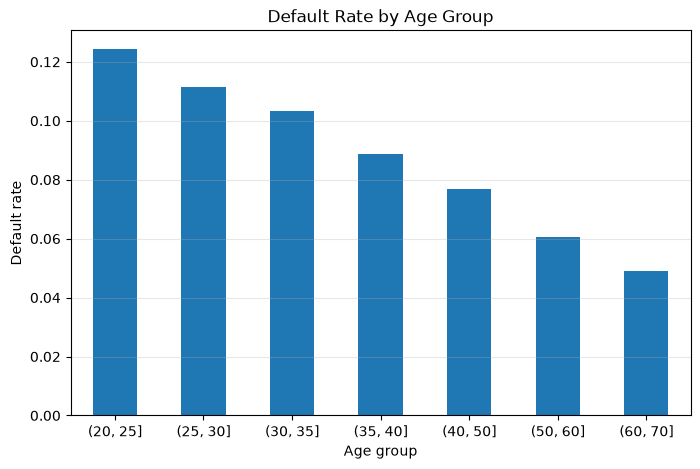

In [24]:
plt.figure(figsize=(8, 5))

age_default["mean"].plot(kind="bar")

plt.xlabel("Age group")
plt.ylabel("Default rate")
plt.title("Default Rate by Age Group")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../reports/figures/default_by_age.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [25]:
cat_cols = dev.select_dtypes(exclude="number").columns

for col in cat_cols:
    n = dev[col].nunique()

    if n <= 10:
        stats = dev.groupby(
            col,
            observed=True
        )["TARGET"].agg(["mean", "count"])

        stats = stats[
            stats["count"] > 500
        ].sort_values("mean", ascending=False)

        print(f"\n=== {col} ===")
        print(stats)


=== NAME_CONTRACT_TYPE ===
                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083447  222560
Revolving loans     0.054930   23448

=== CODE_GENDER ===
                 mean   count
CODE_GENDER                  
M            0.101356   84119
F            0.070012  161887

=== FLAG_OWN_CAR ===
                  mean   count
FLAG_OWN_CAR                  
N             0.084839  162413
Y             0.072744   83595

=== FLAG_OWN_REALTY ===
                     mean   count
FLAG_OWN_REALTY                  
N                0.083114   75318
Y                0.079677  170690

=== NAME_TYPE_SUITE ===
                     mean   count
NAME_TYPE_SUITE                  
Other_B          0.097067    1432
Other_A          0.087518     697
Unaccompanied    0.081918  198808
Spouse, partner  0.078738    9068
Family           0.074501   32080
Children         0.072578    2673

=== NAME_INCOME_TYPE ===
                          mean   count
NAME_INCOME_TY

In [26]:
for col in [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",
    "NAME_FAMILY_STATUS"
]:
    print(f"\n{'=' * 60}")
    print(f"=== {col} ===")
    
    stats = (
        dev.groupby(col, observed=True)["TARGET"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )
    
    print(stats)


=== NAME_INCOME_TYPE ===
                          mean   count
NAME_INCOME_TYPE                      
Unemployed            0.294118      17
Working               0.095385  127043
Commercial associate  0.075917   57273
State servant         0.058454   17518
Pensioner             0.053587   44134
Businessman           0.000000       9
Maternity leave       0.000000       3
Student               0.000000      11

=== NAME_EDUCATION_TYPE ===
                                   mean   count
NAME_EDUCATION_TYPE                            
Lower secondary                0.110744    3025
Secondary / secondary special  0.089158  174768
Incomplete higher              0.086259    8289
Higher education               0.053945   59802
Academic degree                0.016129     124

=== OCCUPATION_TYPE ===
                           mean  count
OCCUPATION_TYPE                       
Low-skill Laborers     0.181014   1696
Waiters/barmen staff   0.114723   1046
Drivers                0.112620  14944

In [27]:
stats = (
    dev.groupby("OCCUPATION_TYPE", observed=True)["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print(stats[stats["count"] > 500])

                           mean  count
OCCUPATION_TYPE                       
Low-skill Laborers     0.181014   1696
Waiters/barmen staff   0.114723   1046
Drivers                0.112620  14944
Security staff         0.106850   5372
Laborers               0.105222  44259
Cooking staff          0.105098   4767
Sales staff            0.095993  25606
Cleaning staff         0.095429   3741
Realty agents          0.080808    594
Secretaries            0.071633   1047
Medicine staff         0.069859   6871
Private service staff  0.065903   2094
Core staff             0.063821  22093
High skill tech staff  0.062796   9093
Managers               0.062237  17096
Accountants            0.046308   7882


In [28]:
stats = (
    dev.groupby("NAME_FAMILY_STATUS", observed=True)["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print(stats[stats["count"] > 500])

                          mean   count
NAME_FAMILY_STATUS                    
Civil marriage        0.100160   23812
Single / not married  0.099453   36359
Separated             0.079861   15840
Married               0.075341  157153
Widow                 0.058714   12842


## EDA Findings

1. **Missingness itself carries signal.** Several variables show meaningful differences in default rate depending on whether their value is missing. The strongest example is the `AMT_REQ_CREDIT_BUREAU_*` group: applicants with missing values have a default rate of 10.34%, compared with 7.72% when the values are present. Missingness indicators should therefore be preserved during feature engineering rather than treating missing values as having no information.

2. **Many variables are heavily missing.** The development set contains 41 columns with more than 50% missing values. Some variables such as `COMMONAREA_AVG` are missing for about 69.84% of applicants, while `EXT_SOURCE_1` is missing for 56.34%. These variables should not automatically be dropped; their missingness and predictive value should be evaluated during modelling.

3. **The EXT_SOURCE variables are among the strongest individual signals.** `EXT_SOURCE_3` has the strongest negative correlation with default at -0.1788, followed by `EXT_SOURCE_2` at -0.1596 and `EXT_SOURCE_1` at -0.1554. Defaulters also have substantially lower average values than non-defaulters. These features should be retained and their missingness should be handled explicitly.

4. **The availability of external scores is itself informative.** Applicants with all three EXT_SOURCE values available have a default rate of 7.32%, compared with 9.94% for applicants with only one available score. Applicants with zero available scores have a default rate of 8.63%. The number of available external scores can therefore be considered as an additional feature.

5. **`DAYS_EMPLOYED` contains a major data-quality anomaly.** 44,143 applicants (17.94%) have `DAYS_EMPLOYED = 365243`, which is a placeholder rather than a realistic employment duration. This group has a default rate of 5.37%, compared with 8.66% for other applicants. The value should therefore be treated as a special missing/unknown category rather than as a genuine numeric duration, while preserving an indicator for the anomaly.

6. **Age has a strong relationship with default risk.** Default rates decline consistently with age: 12.44% for applicants aged 20–25, 11.14% for 25–30, 10.34% for 30–35, 8.89% for 35–40, 7.67% for 40–50, 6.07% for 50–60, and 4.91% for 60–70. `DAYS_BIRTH` should therefore be transformed into an interpretable age feature during feature engineering.

7. **No single numeric feature strongly separates defaulters from non-defaulters.** The strongest individual numeric correlations are only around 0.16–0.18 in magnitude, with `EXT_SOURCE_3` being the strongest at -0.1788. This suggests that useful predictions will come from combining many weak and moderate signals rather than relying on a single variable.

8. **Occupation is strongly associated with default risk.** Among categories with more than 500 applicants, default rates range from 18.10% for low-skill laborers to 4.63% for accountants. Other relatively high-risk groups include waiters/barmen staff (11.47%), drivers (11.26%) and laborers (10.52%), while managers (6.22%) and high-skill tech staff (6.28%) have lower rates. Occupation should therefore be retained as a categorical feature.

9. **Education level is associated with default risk.** Applicants with lower secondary education have a default rate of 11.07%, compared with 8.92% for secondary education and 5.39% for higher education. Education should therefore be retained as a categorical feature rather than discarded.

10. **Family status and contract type also show useful differences.** Civil-marriage and single/not-married applicants have default rates around 10%, compared with 7.53% for married applicants and 5.87% for widowed applicants. Cash loans also have a higher default rate (8.34%) than revolving loans (5.49%). These variables should be retained for the baseline model, while avoiding conclusions from very small categories.